In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
import os
os.chdir('/content/drive/MyDrive/SIG_FDP_materials/handson_notebooks/')

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

data_path = 'indianpinearray.npy'
gt_path = 'IPgt.npy'

data = np.load(data_path)
gt = np.load(gt_path)

print("Data shape:", data.shape)
print("Ground truth shape:", gt.shape)

Data shape: (145, 145, 200)
Ground truth shape: (145, 145)


In [36]:
pip install umap-learn[plot]

In [37]:
import umap
import umap.plot

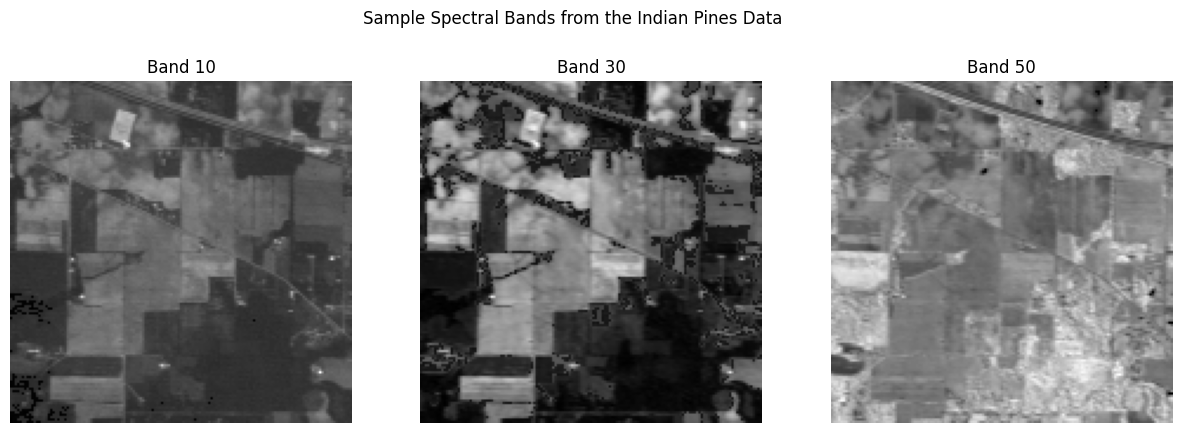

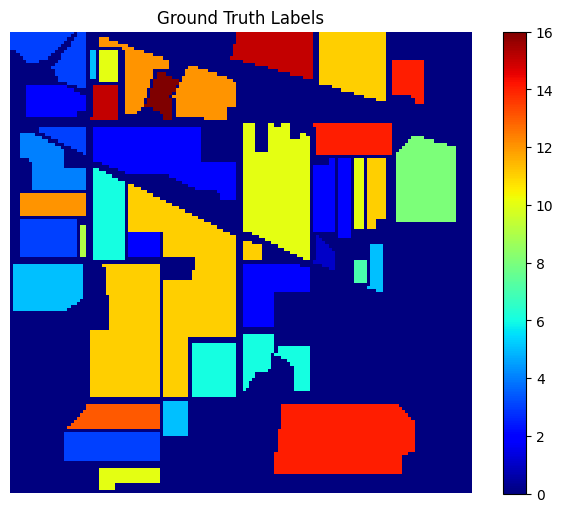

In [38]:
bands_to_show = [10, 30, 50]

fig, axs = plt.subplots(1, len(bands_to_show), figsize=(15, 5))
for i, band in enumerate(bands_to_show):
    axs[i].imshow(data[:, :, band], cmap='gray')
    axs[i].set_title(f'Band {band}')
    axs[i].axis('off')
plt.suptitle("Sample Spectral Bands from the Indian Pines Data")
plt.show()

# Visualize the ground truth
plt.figure(figsize=(8, 6))
plt.imshow(gt, cmap='jet')
plt.title("Ground Truth Labels")
plt.colorbar()
plt.axis('off')
plt.show()

### Prepare Data for Clustering
First, we need to reshape the 3D spectral data into a 2D array suitable for clustering algorithms. We will also flatten the ground truth labels and filter out background pixels (where `gt` is 0) to focus on the labeled regions.

In [39]:
from sklearn.preprocessing import StandardScaler

# Reshape the 3D data (145, 145, 200) to 2D (145*145, 200)
X = data.reshape(-1, data.shape[2])

# Reshape the ground truth (145, 145) to 1D (145*145)
y = gt.reshape(-1)

# Filter out background pixels (where ground truth is 0)
# This is important for clustering, as we only want to cluster actual classes.
nonzero_indices = y != 0
X_filtered = X[nonzero_indices]
y_filtered = y[nonzero_indices]

# Scale the data for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

print("Original data shape (flattened):", X.shape)
print("Ground truth shape (flattened):", y.shape)
print("Filtered data shape (non-zero GT):", X_filtered.shape)
print("Scaled filtered data shape:", X_scaled.shape)
print("Filtered ground truth shape:", y_filtered.shape)

# Determine the number of unique classes (excluding background)
n_clusters = len(np.unique(y_filtered))
print("Number of unique classes (excluding background):", n_clusters)

Original data shape (flattened): (21025, 200)
Ground truth shape (flattened): (21025,)
Filtered data shape (non-zero GT): (10249, 200)
Scaled filtered data shape: (10249, 200)
Filtered ground truth shape: (10249,)
Number of unique classes (excluding background): 16


### K-Means and K-Means++ Clustering on Original Data
Now, we will apply K-means and K-means++ to the scaled, filtered dataset. We will then visualize the results by mapping the cluster labels back to the original image dimensions and comparing them with the ground truth.

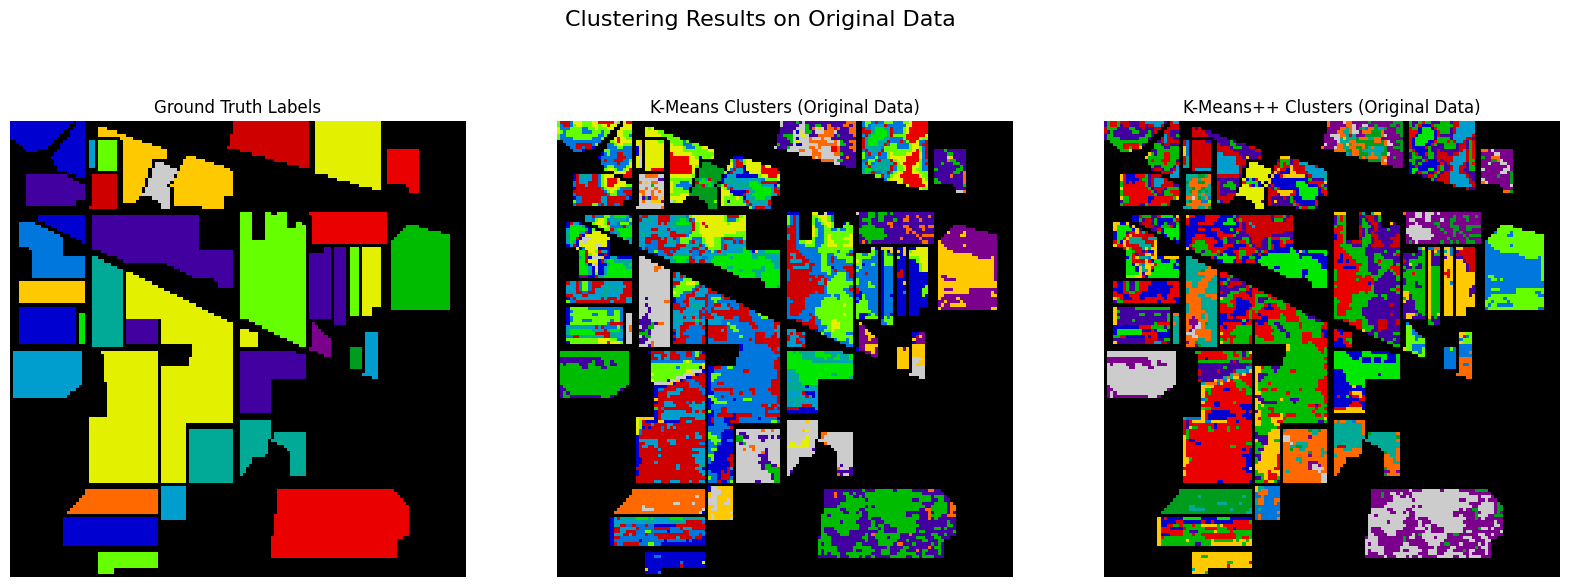

K-Means (Original Data) - Adjusted Rand Index: 0.2226603048437141
K-Means++ (Original Data) - Adjusted Rand Index: 0.22066021082889356
K-Means (Original Data) - Normalized Mutual Information: 0.43083276420262834
K-Means++ (Original Data) - Normalized Mutual Information: 0.4369487287193233


In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# K-Means
kmeans = KMeans(n_clusters=n_clusters, init='random', n_init=10, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# K-Means++
kmeans_plus_plus = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
kmeans_plus_plus_labels = kmeans_plus_plus.fit_predict(X_scaled)

# Map cluster labels back to original image dimensions for visualization
def map_labels_to_image(original_shape, filtered_indices, labels):
    full_labels = np.zeros(original_shape[0] * original_shape[1])
    full_labels[filtered_indices] = labels + 1 # +1 to avoid 0 for background if not already handled
    return full_labels.reshape(original_shape[0], original_shape[1])

kmeans_image = map_labels_to_image(data.shape[:2], nonzero_indices, kmeans_labels)
kmeans_plus_plus_image = map_labels_to_image(data.shape[:2], nonzero_indices, kmeans_plus_plus_labels)

# Plotting the results
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

axs[0].imshow(gt, cmap='nipy_spectral')
axs[0].set_title('Ground Truth Labels')
axs[0].axis('off')

axs[1].imshow(kmeans_image, cmap='nipy_spectral')
axs[1].set_title('K-Means Clusters (Original Data)')
axs[1].axis('off')

axs[2].imshow(kmeans_plus_plus_image, cmap='nipy_spectral')
axs[2].set_title('K-Means++ Clusters (Original Data)')
axs[2].axis('off')

plt.suptitle('Clustering Results on Original Data', fontsize=16)
plt.show()

# Evaluate clustering performance (optional, but good for understanding)
print("K-Means (Original Data) - Adjusted Rand Index:", adjusted_rand_score(y_filtered, kmeans_labels))
print("K-Means++ (Original Data) - Adjusted Rand Index:", adjusted_rand_score(y_filtered, kmeans_plus_plus_labels))
print("K-Means (Original Data) - Normalized Mutual Information:", normalized_mutual_info_score(y_filtered, kmeans_labels))
print("K-Means++ (Original Data) - Normalized Mutual Information:", normalized_mutual_info_score(y_filtered, kmeans_plus_plus_labels))

### UMAP Visualization on Original Data

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


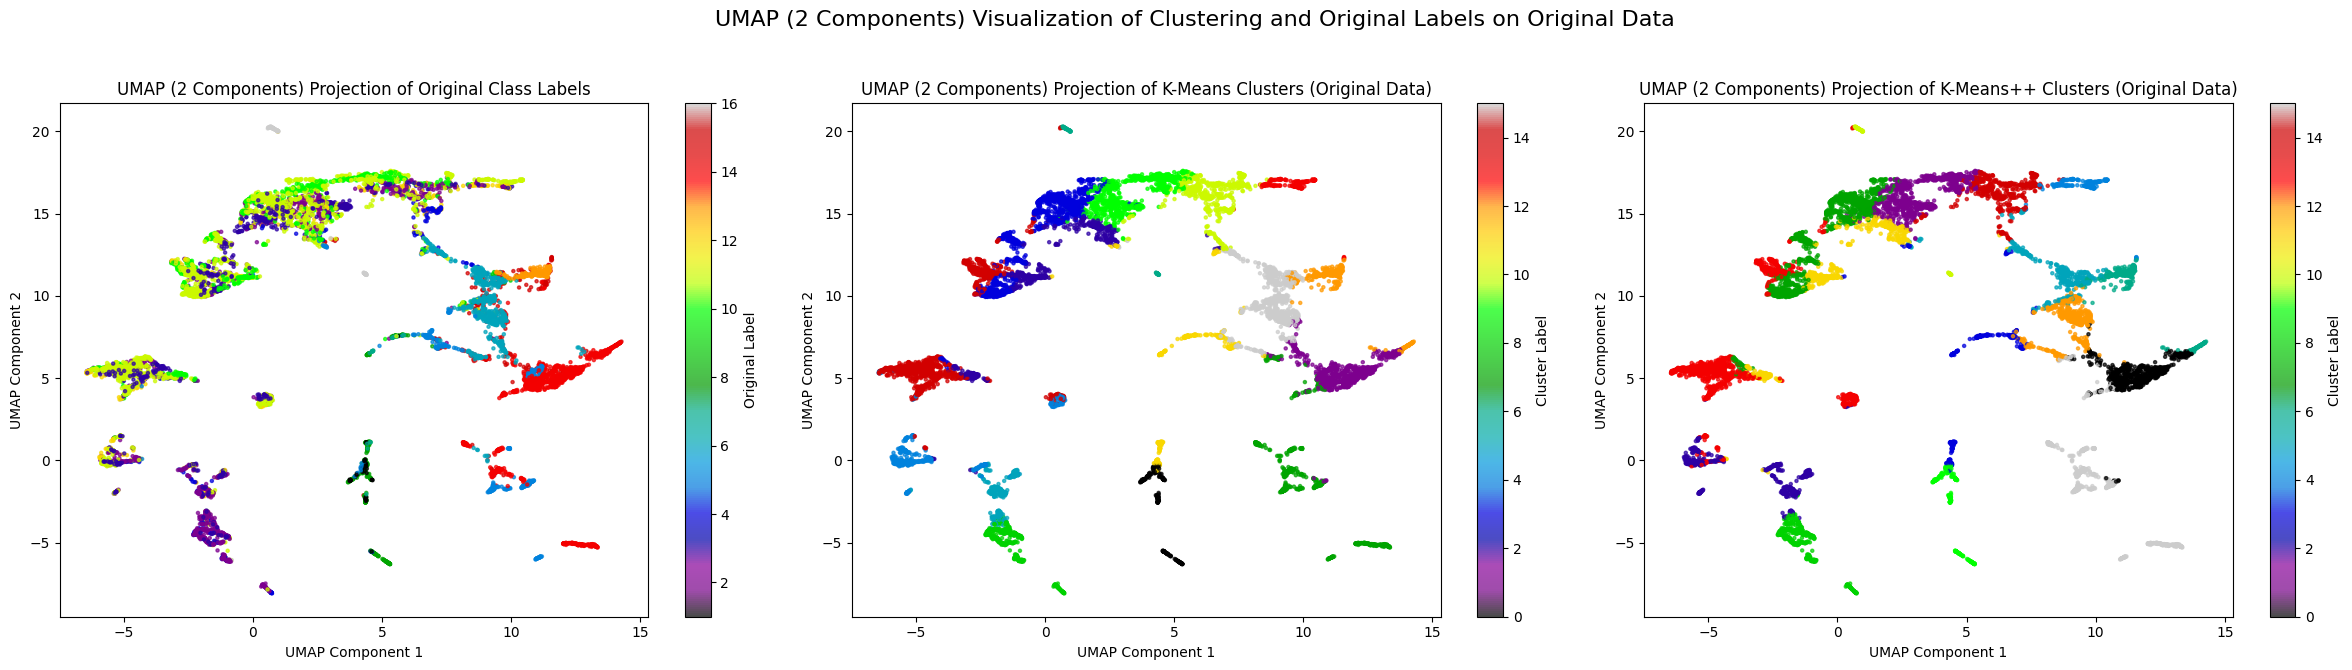

In [41]:
import umap

# Apply UMAP (2 components) to the original scaled data
umap_2d_original = umap.UMAP(n_components=2, random_state=42)
X_umap_2d_original = umap_2d_original.fit_transform(X_scaled)

# Plotting the UMAP (2 components) results for K-Means, K-Means++, and Original Labels on original data
fig, axs = plt.subplots(1, 3, figsize=(24, 7)) # Changed to 3 subplots

# Original Class Labels on UMAP (2 components) projection
scatter0 = axs[0].scatter(X_umap_2d_original[:, 0], X_umap_2d_original[:, 1], c=y_filtered, cmap='nipy_spectral', s=5, alpha=0.7)
axs[0].set_title('UMAP (2 Components) Projection of Original Class Labels')
axs[0].set_xlabel('UMAP Component 1')
axs[0].set_ylabel('UMAP Component 2')
plt.colorbar(scatter0, ax=axs[0], label='Original Label')

# K-Means clusters on UMAP (2 components) projection
scatter1 = axs[1].scatter(X_umap_2d_original[:, 0], X_umap_2d_original[:, 1], c=kmeans_labels, cmap='nipy_spectral', s=5, alpha=0.7)
axs[1].set_title('UMAP (2 Components) Projection of K-Means Clusters (Original Data)')
axs[1].set_xlabel('UMAP Component 1')
axs[1].set_ylabel('UMAP Component 2')
plt.colorbar(scatter1, ax=axs[1], label='Cluster Label')

# K-Means++ clusters on UMAP (2 components) projection
scatter2 = axs[2].scatter(X_umap_2d_original[:, 0], X_umap_2d_original[:, 1], c=kmeans_plus_plus_labels, cmap='nipy_spectral', s=5, alpha=0.7)
axs[2].set_title('UMAP (2 Components) Projection of K-Means++ Clusters (Original Data)')
axs[2].set_xlabel('UMAP Component 1')
axs[2].set_ylabel('UMAP Component 2')
plt.colorbar(scatter2, ax=axs[2], label='Cluster Label')

plt.suptitle('UMAP (2 Components) Visualization of Clustering and Original Labels on Original Data', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Dimensionality Reduction using PCA
Before applying clustering after PCA, let's reduce the dimensionality of our data. We'll choose a number of components that retains a significant amount of variance.

Original number of features: 200
Reduced number of features after PCA: 50
Explained variance ratio of selected components: 0.9940598825435678


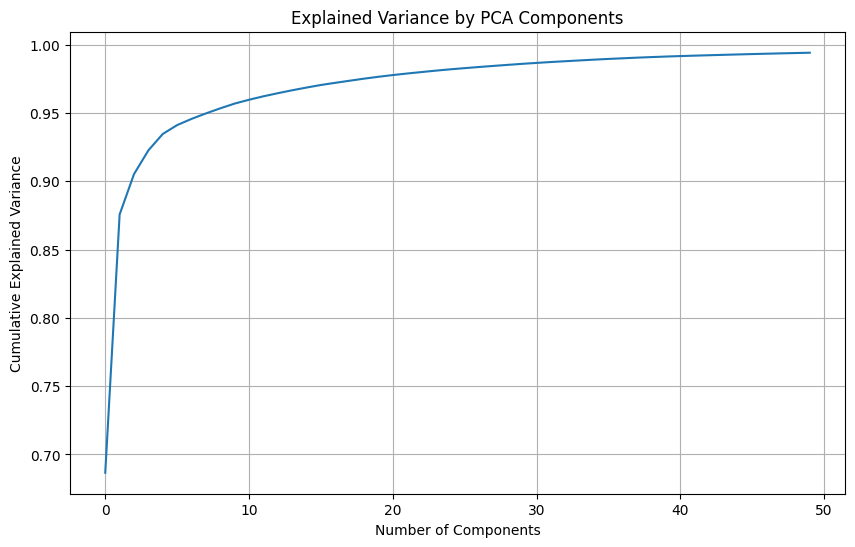

In [42]:
from sklearn.decomposition import PCA

# Apply PCA. Let's choose a number of components, e.g., 50 or based on explained variance.
# For visualization later with 2D/3D plots, we might choose 2 or 3 components.
# For clustering, it's often better to retain more variance.
pca = PCA(n_components=50) # You can adjust this number
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X_scaled.shape[1])
print("Reduced number of features after PCA:", X_pca.shape[1])
print("Explained variance ratio of selected components:", np.sum(pca.explained_variance_ratio_))

# Optional: Plot explained variance to help choose n_components
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.show()

### K-Means and K-Means++ Clustering after PCA
Now we will apply K-means and K-means++ to the PCA-transformed data and visualize the results.

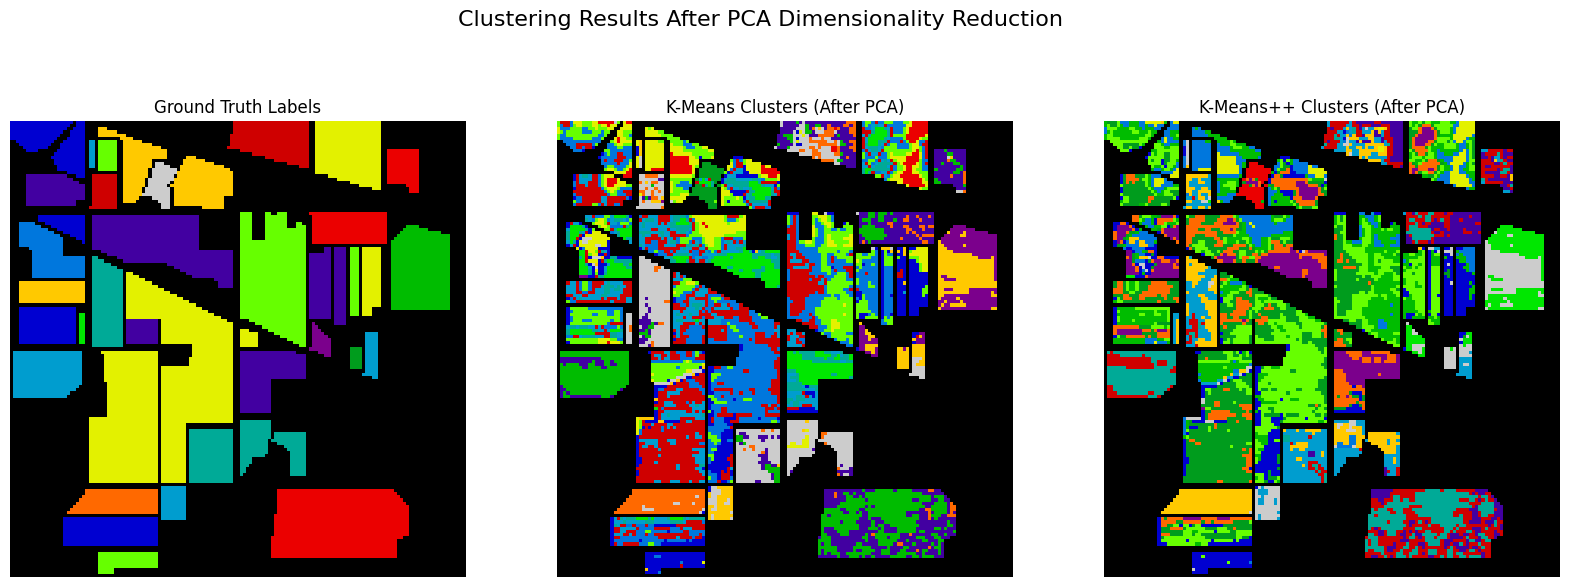

K-Means (After PCA) - Adjusted Rand Index: 0.2227550720597322
K-Means++ (After PCA) - Adjusted Rand Index: 0.20554243941809683
K-Means (After PCA) - Normalized Mutual Information: 0.43088578154822343
K-Means++ (After PCA) - Normalized Mutual Information: 0.4293407915176264


In [43]:
# K-Means on PCA data
kmeans_pca = KMeans(n_clusters=n_clusters, init='random', n_init=10, random_state=42)
kmeans_pca_labels = kmeans_pca.fit_predict(X_pca)

# K-Means++ on PCA data
kmeans_plus_plus_pca = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
kmeans_plus_plus_pca_labels = kmeans_plus_plus_pca.fit_predict(X_pca)

# Map cluster labels back to original image dimensions for visualization
kmeans_pca_image = map_labels_to_image(data.shape[:2], nonzero_indices, kmeans_pca_labels)
kmeans_plus_plus_pca_image = map_labels_to_image(data.shape[:2], nonzero_indices, kmeans_plus_plus_pca_labels)

# Plotting the results
fig, axs = plt.subplots(1, 3, figsize=(20, 7))

axs[0].imshow(gt, cmap='nipy_spectral')
axs[0].set_title('Ground Truth Labels')
axs[0].axis('off')

axs[1].imshow(kmeans_pca_image, cmap='nipy_spectral')
axs[1].set_title('K-Means Clusters (After PCA)')
axs[1].axis('off')

axs[2].imshow(kmeans_plus_plus_pca_image, cmap='nipy_spectral')
axs[2].set_title('K-Means++ Clusters (After PCA)')
axs[2].axis('off')

plt.suptitle('Clustering Results After PCA Dimensionality Reduction', fontsize=16)
plt.show()

# Evaluate clustering performance
print("K-Means (After PCA) - Adjusted Rand Index:", adjusted_rand_score(y_filtered, kmeans_pca_labels))
print("K-Means++ (After PCA) - Adjusted Rand Index:", adjusted_rand_score(y_filtered, kmeans_plus_plus_pca_labels))
print("K-Means (After PCA) - Normalized Mutual Information:", normalized_mutual_info_score(y_filtered, kmeans_pca_labels))
print("K-Means++ (After PCA) - Normalized Mutual Information:", normalized_mutual_info_score(y_filtered, kmeans_plus_plus_pca_labels))

### UMAP Visualization After PCA

In [ ]:
import umap

# Apply UMAP (2 components) to the PCA-reduced data (X_pca)
umap_2d_post_pca = umap.UMAP(n_components=2, random_state=42)
X_umap_2d_post_pca = umap_2d_post_pca.fit_transform(X_pca)

# Plotting the UMAP (2 components) results for K-Means, K-Means++ and Original Labels on PCA data
fig, axs = plt.subplots(1, 3, figsize=(24, 7)) # Changed to 3 subplots

# Original Class Labels on UMAP (2 components) projection
scatter0 = axs[0].scatter(X_umap_2d_post_pca[:, 0], X_umap_2d_post_pca[:, 1], c=y_filtered, cmap='nipy_spectral', s=5, alpha=0.7)
axs[0].set_title('UMAP (2 Components) Projection of Original Class Labels (After Initial PCA)')
axs[0].set_xlabel('UMAP Component 1')
axs[0].set_ylabel('UMAP Component 2')
plt.colorbar(scatter0, ax=axs[0], label='Original Label')

# K-Means clusters on UMAP (2 components) projection
scatter1 = axs[1].scatter(X_umap_2d_post_pca[:, 0], X_umap_2d_post_pca[:, 1], c=kmeans_pca_labels, cmap='nipy_spectral', s=5, alpha=0.7)
axs[1].set_title('UMAP (2 Components) Projection of K-Means Clusters (After Initial PCA)')
axs[1].set_xlabel('UMAP Component 1')
axs[1].set_ylabel('UMAP Component 2')
plt.colorbar(scatter1, ax=axs[1], label='Cluster Label')

# K-Means++ clusters on UMAP (2 components) projection
scatter2 = axs[2].scatter(X_umap_2d_post_pca[:, 0], X_umap_2d_post_pca[:, 1], c=kmeans_plus_plus_pca_labels, cmap='nipy_spectral', s=5, alpha=0.7)
axs[2].set_title('UMAP (2 Components) Projection of K-Means++ Clusters (After Initial PCA)')
axs[2].set_xlabel('UMAP Component 1')
axs[2].set_ylabel('UMAP Component 2')
plt.colorbar(scatter2, ax=axs[2], label='Cluster Label')

plt.suptitle('UMAP (2 Components) Visualization of Clustering and Original Labels After Initial PCA Dimensionality Reduction', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
